# Project Name - Uber Demand-Supply Gap Analysis


## Project Summary

The objective of this project is to perform Exploratory Data Analysis (EDA) on Uber ride request data to identify demand-supply gaps, ride completion trends, cancellation patterns, and driver availability issues.

The analysis focuses on:
- Ride request distribution
- Trip completion rate
- Cancellation trends
- No Cars Available cases
- Pickup point analysis
- Time slot and hourly demand patterns

The insights generated can help improve driver allocation and reduce ride failures.

## Problem Statement

Uber experiences ride request failures due to trip cancellations and driver unavailability.

This project aims to identify:
- When ride demand is highest
- Which pickup points face the largest supply gap
- Time slots with maximum ride failures
- Driver availability patterns
- Opportunities to improve ride completion rates

## Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [5]:
df = pd.read_csv("Raw Data.csv")

In [6]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Request Hour,Weekday,Time Slot,Driver Assigned,Trip Completed?
0,619,Airport,1.0,Trip Completed,11-07-2016 11:51,11-07-2016 13:00,11,Monday,Morning,Yes,Yes
1,867,Airport,1.0,Trip Completed,11-07-2016 17:57,11-07-2016 18:47,17,Monday,Evening,Yes,Yes
2,1807,City,1.0,Trip Completed,12-07-2016 09:17,12-07-2016 09:58,9,Tuesday,Morning,Yes,Yes
3,2532,Airport,1.0,Trip Completed,12-07-2016 21:08,12-07-2016 22:03,21,Tuesday,Night,Yes,Yes
4,3112,City,1.0,Trip Completed,13-07-2016 08:33,13-07-2016 09:25,8,Wednesday,Early Morning,Yes,Yes


## Dataset Overview

In [7]:
df.shape

(6745, 11)

In [8]:
df.columns

Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp', 'Request Hour', 'Weekday',
       'Time Slot', 'Driver Assigned', 'Trip Completed?'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
 6   Request Hour       6745 non-null   int64  
 7   Weekday            6745 non-null   object 
 8   Time Slot          6745 non-null   object 
 9   Driver Assigned    6745 non-null   object 
 10  Trip Completed?    6745 non-null   object 
dtypes: float64(1), int64(2), object(8)
memory usage: 579.8+ KB


In [10]:
df.describe()

,Request id,Driver id,Request Hour
count,6745.000000,4095.000000,6745.000000
mean,3384.644922,149.501343,12.956709
std,1955.099667,86.051994,6.504052
min,1.000000,1.000000,0.000000
25%,1691.000000,75.000000,7.000000
50%,3387.000000,149.000000,13.000000
75%,5080.000000,224.000000,19.000000
max,6766.000000,300.000000,23.000000


## Data Wrangling

In [11]:
df.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
Request Hour            0
Weekday                 0
Time Slot               0
Driver Assigned         0
Trip Completed?         0
dtype: int64

### Missing Values Analysis

- No missing values are present in most columns.
- Driver id contains 2650 missing values.
- Drop timestamp contains 3914 missing values.
- These missing values are expected because:
  - "No Cars Available" requests do not have a driver assigned.
  - Cancelled and No Cars Available requests may not have a drop timestamp.
- Therefore, these missing values represent business scenarios and will not be removed.

In [12]:
df.duplicated().sum()

np.int64(0)

### Duplicate Records Analysis

- No duplicate records were found in the dataset.
- Each ride request is unique and can be safely used for analysis.

In [13]:
df.nunique()

Request id           6745
Pickup point            2
Driver id             300
Status                  3
Request timestamp    4016
Drop timestamp       2282
Request Hour           24
Weekday                 5
Time Slot               6
Driver Assigned         2
Trip Completed?         2
dtype: int64

### Observations

- Dataset contains 6745 records and 11 columns.
- No duplicate records are present.
- Status contains three categories:
  - Trip Completed
  - Cancelled
  - No Cars Available
- Additional helper columns were created for better analysis:
  - Request Hour
  - Weekday
  - Time Slot
  - Driver Assigned
  - Trip Completed

In [14]:
df['Status'].value_counts()

Status
Trip Completed       2831
No Cars Available    2650
Cancelled            1264
Name: count, dtype: int64

### Status Distribution Analysis

- Trip Completed is the most frequent ride status with 2,831 requests.
- No Cars Available accounts for 2,650 requests, indicating a significant supply shortage.
- Cancelled rides account for 1,264 requests.
- Successful trips represent the largest category, but failed requests (Cancelled + No Cars Available) are higher than completed trips.
- This suggests a noticeable demand-supply gap in the Uber ride network.

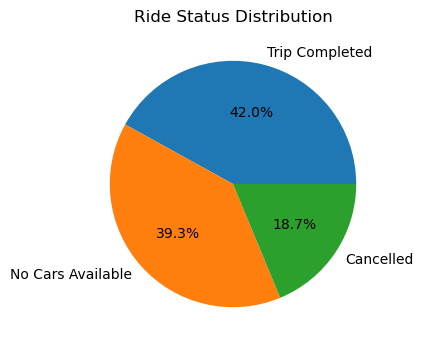

In [15]:
status_counts = df['Status'].value_counts()

status_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(4,4)
)

plt.title('Ride Status Distribution')
plt.ylabel('')
plt.show()

### Insights

- Trip Completed accounts for 42.0% of total requests, making it the largest category.
- No Cars Available contributes 39.3% of requests, indicating a significant driver shortage.
- Cancelled rides account for 18.7% of total requests.
- More than half of the ride requests (58%) were unsuccessful due to cancellations or unavailability of drivers.
- Reducing driver shortages during peak demand periods could significantly improve the trip completion rate.

## Pickup Point Analysis

In [16]:
df['Pickup point'].value_counts()

Pickup point
City       3507
Airport    3238
Name: count, dtype: int64

### Pickup Point Distribution Analysis

- The City pickup point generated 3,507 ride requests.
- The Airport pickup point generated 3,238 ride requests.
- Demand is slightly higher in the City compared to the Airport.
- Both pickup locations contribute almost equally to the total ride demand.

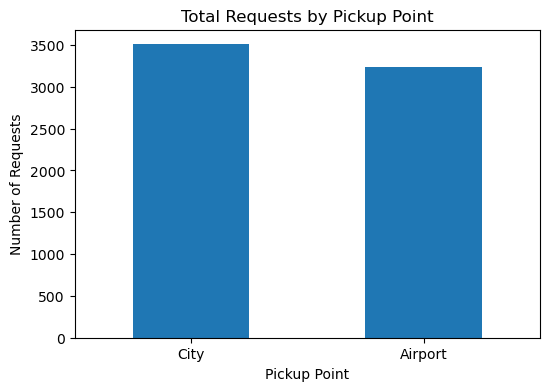

In [17]:
pickup_counts = df['Pickup point'].value_counts()

pickup_counts.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Total Requests by Pickup Point')
plt.xlabel('Pickup Point')
plt.ylabel('Number of Requests')
plt.xticks(rotation = 0)

plt.show()

### Insights

- City generated 3,507 requests, slightly higher than Airport with 3,238 requests.
- The demand difference between the two pickup points is relatively small.
- Both pickup points contribute significantly to Uber's overall ride demand.
- Resource planning should consider both locations equally, as demand is distributed across City and Airport pickups.

## Time Slot Analysis

In [18]:
df['Time Slot'].value_counts()

Time Slot
Evening          1893
Early Morning    1672
Night             947
Morning           845
Afternoon         810
Late Night        578
Name: count, dtype: int64

### Time Slot Distribution Analysis

- Evening recorded the highest number of requests (1,893).
- Early Morning is the second busiest time slot with 1,672 requests.
- Night, Morning, and Afternoon show moderate demand levels.
- Late Night has the lowest number of ride requests (578).
- Demand is concentrated during Evening and Early Morning hours, indicating peak travel periods.

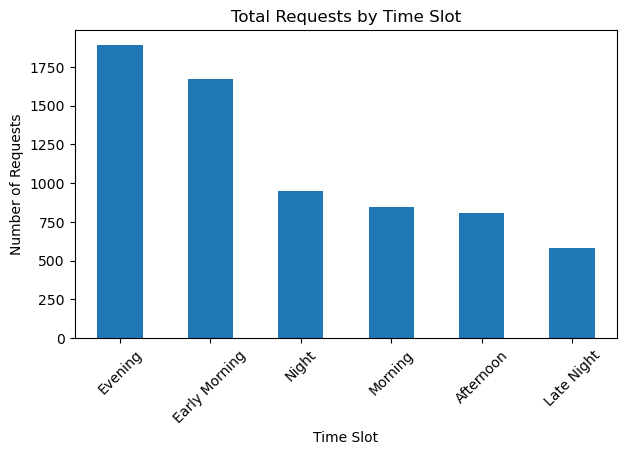

In [19]:
time_slot_counts = df['Time Slot'].value_counts()

time_slot_counts.plot(
    kind='bar',
    figsize=(7,4)
)

plt.title('Total Requests by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Number of Requests')
plt.xticks(rotation=45)

plt.show()

### Insights

- Evening is the busiest time slot with 1,893 ride requests.
- Early Morning follows closely with 1,672 requests.
- Late Night records the lowest demand with only 578 requests.
- Demand is concentrated during commuting hours, especially in the Evening and Early Morning periods.
- Uber should prioritize driver availability during these peak demand periods to reduce service failures.

## Trip Status by Pickup Point

In [20]:
pd.crosstab(df['Pickup point'], df['Status'])

Status,Cancelled,No Cars Available,Trip Completed
Pickup point,,,
Airport,198,1713,1327
City,1066,937,1504


### Trip Status by Pickup Point Analysis

- Airport recorded 1,713 requests with no cars available, which is the highest among all status categories.
- City recorded 1,504 completed trips, making it the location with the highest successful ride completions.
- Cancellations are significantly higher in the City (1,066) compared to the Airport (198).
- Airport mainly suffers from driver unavailability, while City experiences more ride cancellations.
- The demand-supply gap differs across pickup locations and requires different operational strategies.

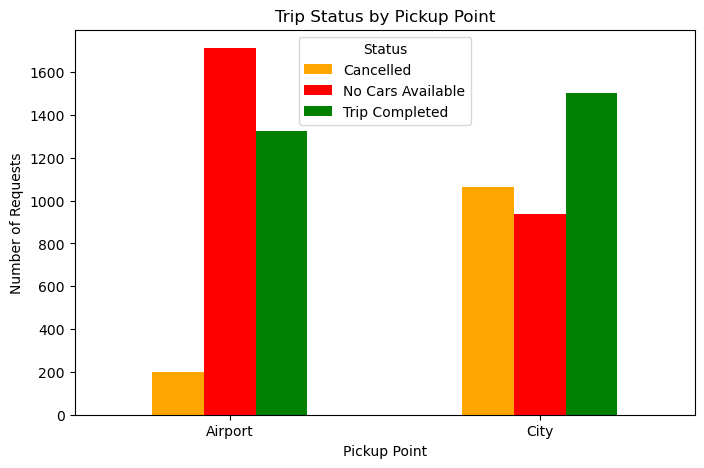

In [21]:
pickup_status = pd.crosstab(df['Pickup point'], df['Status'])

pickup_status.plot(
    kind='bar',
    figsize=(8,5),
    color=['Orange', 'Red', 'Green']
)

plt.title('Trip Status by Pickup Point')
plt.xlabel('Pickup Point')
plt.ylabel('Number of Requests')
plt.xticks(rotation=0)

plt.show()

### Insights

- Airport experiences a severe driver shortage, with 1,713 requests marked as "No Cars Available".
- City records the highest number of cancellations (1,066), indicating operational challenges despite better driver availability.
- Completed trips are highest in the City (1,504), showing relatively better service fulfillment.
- The primary issue at Airport is driver unavailability, whereas the City faces more customer or driver cancellations.
- Different strategies are required for each pickup point to reduce failed ride requests.

In [22]:
pd.crosstab(df['Time Slot'], df['Status'])

Status,Cancelled,No Cars Available,Trip Completed
Time Slot,,,
Afternoon,91,228,491
Early Morning,668,323,681
Evening,124,1127,642
Late Night,65,299,214
Morning,252,189,404
Night,64,484,399


### Trip Status by Time Slot Analysis

- Evening has the highest number of "No Cars Available" requests (1,127), indicating a severe driver shortage.
- Early Morning records the highest number of cancellations (668).
- Trip completions are highest during Early Morning (681) and Evening (642).
- Late Night has the lowest demand and relatively fewer failed requests.
- Demand-supply issues are most prominent during Evening and Early Morning periods.

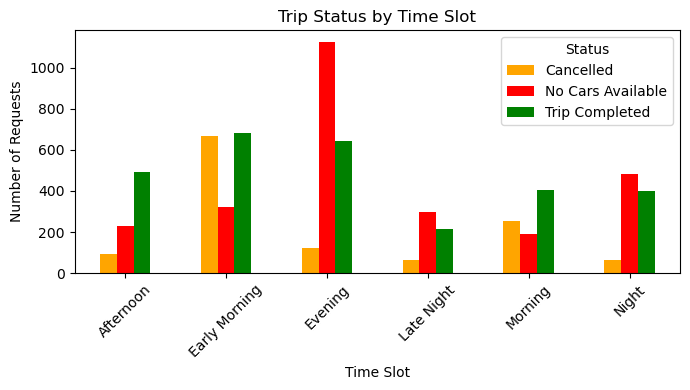

In [23]:
time_status = pd.crosstab(df['Time Slot'], df['Status'])

time_status.plot(
    kind='bar',
    figsize=(7,4),
    color=['Orange', 'Red', 'Green']
)

plt.title('Trip Status by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Number of Requests')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Insights

- Evening shows the largest demand-supply gap due to the extremely high number of requests with no cars available.
- Early Morning experiences the highest ride cancellations, suggesting operational inefficiencies during this period.
- Despite high demand, Evening and Early Morning also record the highest number of completed trips.
- Driver availability should be increased during Evening hours to reduce unmet demand.
- Improving ride allocation and driver scheduling during Early Morning could significantly reduce cancellations.

## Hourly Demand Analysis

In [24]:
df['Request Hour'].value_counts().sort_index()

Request Hour
0      99
1      85
2      99
3      92
4     203
5     445
6     398
7     406
8     423
9     431
10    243
11    171
12    184
13    160
14    136
15    171
16    159
17    418
18    510
19    473
20    492
21    449
22    304
23    194
Name: count, dtype: int64

### Hourly Request Analysis

- Ride requests remain low between 12 AM and 4 AM.
- Demand starts increasing significantly from 5 AM onwards.
- A morning peak is observed between 5 AM and 9 AM.
- Request volume decreases during afternoon hours.
- Another major peak occurs between 5 PM and 9 PM.
- The highest number of requests is recorded at 6 PM (510 requests).
- Evening hours represent the busiest period of the day for Uber services.

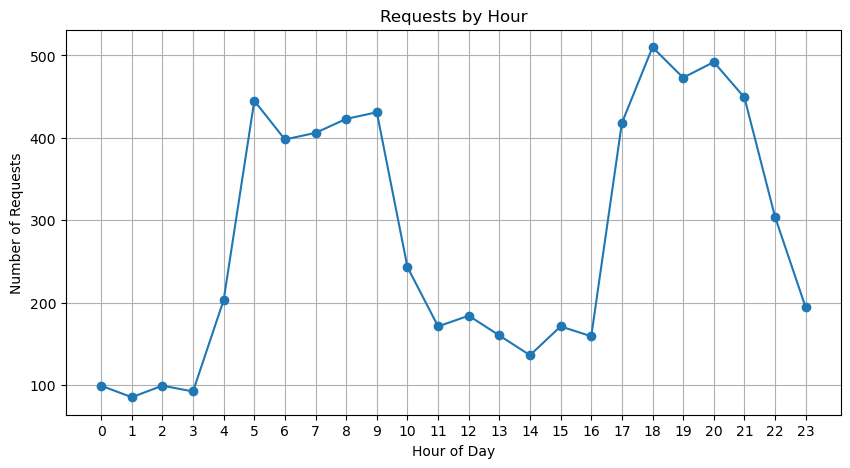

In [25]:
hourly_requests = df['Request Hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    hourly_requests.index,
    hourly_requests.values,
    marker='o'
)

plt.title('Requests by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')

plt.xticks(range(24))
plt.grid(True)

plt.show()

### Insights

- Two distinct demand peaks are visible: Morning (5 AM–9 AM) and Evening (5 PM–9 PM).
- The highest demand occurs at 6 PM with 510 ride requests.
- Demand is lowest during late-night and early-morning hours.
- The Evening peak is stronger than the Morning peak, indicating increased travel demand after working hours.
- Uber should increase driver availability during peak hours to reduce unmet demand and improve ride completion rates.

## Weekday Analysis

In [26]:
df['Weekday'].value_counts()

Weekday
Friday       1381
Monday       1367
Thursday     1353
Wednesday    1337
Tuesday      1307
Name: count, dtype: int64

### Weekday Distribution Analysis

- The dataset contains ride requests from Monday to Friday only.
- Friday recorded the highest number of requests (1,381).
- Tuesday recorded the lowest number of requests (1,307).
- The difference in request volume across weekdays is relatively small.
- Ride demand remains fairly consistent throughout the working week.

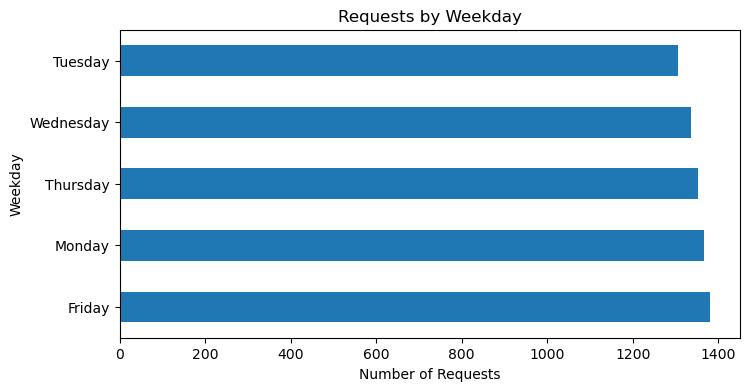

In [27]:
weekday_counts = df['Weekday'].value_counts()

weekday_counts.plot(
    kind='barh',
    figsize=(8,4)
)

plt.title('Requests by Weekday')
plt.xlabel('Number of Requests')
plt.ylabel('Weekday')

plt.show()

### Insights

- Friday is the busiest day with 1,381 ride requests.
- Tuesday has the lowest demand with 1,307 requests.
- Demand remains relatively stable throughout the week.
- No significant weekday fluctuations are observed.
- Driver allocation can remain relatively consistent across weekdays.

In [28]:
pd.crosstab(df['Weekday'], df['Status'])

Status,Cancelled,No Cars Available,Trip Completed
Weekday,,,
Friday,240,580,561
Monday,262,504,601
Thursday,252,571,530
Tuesday,240,505,562
Wednesday,270,490,577


### Weekday vs Trip Status Analysis

- Monday recorded the highest number of completed trips (601).
- Friday recorded the highest number of No Cars Available cases (580).
- Wednesday experienced the highest number of cancellations (270).
- Completed trips remain relatively consistent across all weekdays.
- Driver shortages are a bigger concern than cancellations throughout the week.

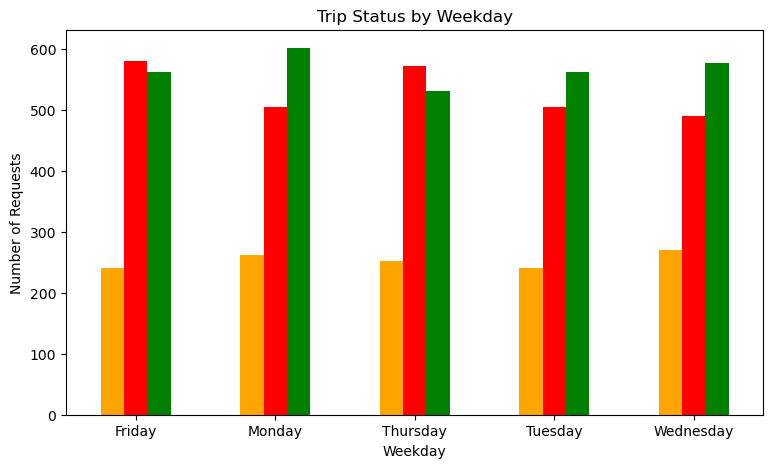

In [29]:
weekday_status = pd.crosstab(df['Weekday'], df['Status'])

weekday_status.plot(
    kind='bar',
    figsize=(9,5),
    color=['Orange', 'Red', 'Green']
)

plt.title('Trip Status by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Number of Requests')
plt.xticks(rotation=0)
plt.legend().remove()

plt.show()

### Insights

- Driver unavailability remains a major issue across all weekdays.
- Friday records the highest number of unmet ride requests due to No Cars Available.
- Monday achieves the highest number of successful trip completions.
- Cancellation levels remain fairly stable throughout the week.
- Improving driver availability can significantly increase ride completion rates.

# Key Findings

1. Only 41.97% of ride requests were successfully completed.

2. No Cars Available (39.29%) is the primary reason for ride failures.

3. Airport suffers from severe driver shortages, while City experiences more cancellations.

4. Evening and Early Morning are the busiest time slots and face the highest demand-supply gaps.

5. The highest ride demand occurs during evening hours, peaking at 6 PM.

6. Driver shortages have a greater impact on ride failures than cancellations.

# Conclusion

The analysis reveals a significant demand-supply gap in Uber's ride request system. Driver unavailability is the primary cause of unsuccessful ride requests, especially during Evening and Early Morning periods. Airport pickup locations experience a high number of unmet requests due to insufficient driver availability, while City locations face more cancellations.

To improve service quality, Uber should increase driver availability during peak demand hours and optimize driver allocation across pickup locations. These measures can improve ride completion rates, reduce customer dissatisfaction, and enhance overall operational efficiency.